In [ ]:
import pandas as pd

df = pd.read_excel("youtube_yorumlar_tam.xlsx")
print(f"Toplam yorum: {len(df)}")
print(f"Sütunlar: {df.columns.tolist()}")
print(df.head(3))

Toplam yorum: 66532
Sütunlar: ['video_id', 'film_adi', 'kategori', 'yorum', 'begeni', 'Unnamed: 5', 'Unnamed: 6']
      video_id        film_adi          kategori  \
0  Way9Dexny3w  Dune: Part Two  Aksiyon & Macera   
1  Way9Dexny3w  Dune: Part Two  Aksiyon & Macera   
2  Way9Dexny3w  Dune: Part Two  Aksiyon & Macera   

                                               yorum begeni  Unnamed: 5  \
0               Who’s here after the Dune P3 Trailer   1256         NaN   
1                   Star Wars is dead, Dune is king.  13554         NaN   
2  They pulled lines directly from the book, spec...  18653         NaN   

  Unnamed: 6  
0        NaN  
1        NaN  
2        NaN  


In [ ]:
!pip install transformers torch -q

In [ ]:
import torch
print(f"GPU var mı: {torch.cuda.is_available()}")
print(f"GPU adı: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'YOK'}")

GPU var mı: True
GPU adı: Tesla T4


In [ ]:
import pandas as pd

print("="*50)
print("VERİ GENEL BAKIŞ")
print("="*50)
print(f"Toplam yorum: {len(df)}")
print(f"Sütunlar: {df.columns.tolist()}")
print(f"\nEksik değerler:")
print(df.isnull().sum())

print(f"\nVeri tipleri:")
print(df.dtypes)

print(f"\nFilm başına yorum sayısı:")
print(df["film_adi"].value_counts())

print(f"\nBeğeni istatistikleri:")
print(df["begeni"].describe())

VERİ GENEL BAKIŞ
Toplam yorum: 66532
Sütunlar: ['video_id', 'film_adi', 'kategori', 'yorum', 'begeni', 'Unnamed: 5', 'Unnamed: 6']

Eksik değerler:
video_id          0
film_adi          0
kategori          0
yorum             5
begeni            0
Unnamed: 5    66531
Unnamed: 6    66531
dtype: int64

Veri tipleri:
video_id       object
film_adi       object
kategori       object
yorum          object
begeni         object
Unnamed: 5    float64
Unnamed: 6     object
dtype: object

Film başına yorum sayısı:
film_adi
The Northman                 599
John Wick 4                  500
Dune: Part Two               500
The Batman                   500
Gladiator II                 500
                            ... 
Presence 2024                129
Azrael 2024                  104
Immaculate Sydney Sweeney     99
Cuckoo 2024                   83
The Bikeriders                44
Name: count, Length: 139, dtype: int64

Beğeni istatistikleri:
count     66532
unique     3228
top           0
freq  

In [ ]:
df_temiz = df.copy()

# 1. Boş yorumları sil
once = len(df_temiz)
df_temiz = df_temiz.dropna(subset=["yorum"])
print(f"Boş yorum silindi: {once - len(df_temiz)}")

# 2. Çok kısa yorumları sil (3 kelimeden az)
once = len(df_temiz)
df_temiz = df_temiz[df_temiz["yorum"].str.split().str.len() >= 3]
print(f"Kısa yorum silindi: {once - len(df_temiz)}")

# 3. Mükerrer yorumları sil
once = len(df_temiz)
df_temiz = df_temiz.drop_duplicates(subset=["yorum"])
print(f"Mükerrer yorum silindi: {once - len(df_temiz)}")

# 4. Sadece emoji/sembol olan yorumları sil
once = len(df_temiz)
df_temiz = df_temiz[df_temiz["yorum"].str.len() >= 10]
print(f"Sembol yorum silindi: {once - len(df_temiz)}")

# 5. Beğeni sütununu sayıya çevir
df_temiz["begeni"] = pd.to_numeric(df_temiz["begeni"], errors="coerce").fillna(0).astype(int)

print(f"\n{'='*50}")
print(f"Temizlik öncesi: {len(df)} yorum")
print(f"Temizlik sonrası: {len(df_temiz)} yorum")
print(f"Silinen toplam: {len(df) - len(df_temiz)} yorum")
print(f"{'='*50}")

print(f"\nBeğeni dağılımı:")
print(df_temiz["begeni"].describe())
print(f"\nBeğeni > 0 olan yorum sayısı: {(df_temiz['begeni'] > 0).sum()}")
print(f"Beğeni = 0 olan yorum sayısı: {(df_temiz['begeni'] == 0).sum()}")

Boş yorum silindi: 5
Kısa yorum silindi: 2898
Mükerrer yorum silindi: 756
Sembol yorum silindi: 22

Temizlik öncesi: 66532 yorum
Temizlik sonrası: 62851 yorum
Silinen toplam: 3681 yorum

Beğeni dağılımı:
count     62851.000000
mean        290.361060
std        2200.590088
min           0.000000
25%           0.000000
50%           4.000000
75%          42.000000
max      163216.000000
Name: begeni, dtype: float64

Beğeni > 0 olan yorum sayısı: 46587
Beğeni = 0 olan yorum sayısı: 16264


In [ ]:
# Ağırlıklı duygu skoru formülü:
#
# Ham skor   → modelin verdiği güven skoru (0-1)
# Ağırlık    → log(begeni + 1) — sıfır beğeniyi de kapsar
#
# Ağırlıklı skor = duygu_skoru × log(begeni + 1)
#
# Film bazında ağırlıklı pozitif oran:
# = Σ(pozitif_skor × ağırlık) / Σ(ağırlık)

import numpy as np

# Önizleme — beğeni dağılımı
df_temiz["begeni_log"] = np.log1p(df_temiz["begeni"])

print("Beğeni log dağılımı:")
print(df_temiz["begeni_log"].describe())

# Beğeni segmentleri
df_temiz["begeni_segment"] = pd.cut(
    df_temiz["begeni"],
    bins=[-1, 0, 10, 100, 1000, float("inf")],
    labels=["0", "1-10", "11-100", "101-1000", "1000+"]
)
print("\nBeğeni segmentleri:")
print(df_temiz["begeni_segment"].value_counts())

Beğeni log dağılımı:
count    62851.000000
mean         2.272219
std          2.312990
min          0.000000
25%          0.000000
50%          1.609438
75%          3.761200
max         12.002836
Name: begeni_log, dtype: float64

Beğeni segmentleri:
begeni_segment
1-10        23677
0           16264
11-100      11370
101-1000     8585
1000+        2955
Name: count, dtype: int64


In [ ]:
from transformers import pipeline
from tqdm import tqdm
import numpy as np

sentiment = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512,
    device=0  # GPU
)

# Test
print(sentiment("This movie looks absolutely amazing!"))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

[{'label': 'positive', 'score': 0.9854192733764648}]


In [ ]:
duygu_listesi = []
skor_listesi = []

batch_size = 64
for i in tqdm(range(0, len(df_temiz), batch_size)):
    batch = df_temiz["yorum"].iloc[i:i+batch_size].fillna("").tolist()
    batch = [str(y)[:512] for y in batch]

    try:
        sonuclar = sentiment(batch)
        for s in sonuclar:
            duygu_listesi.append(s["label"])
            skor_listesi.append(round(s["score"], 3))
    except:
        for _ in batch:
            duygu_listesi.append("unknown")
            skor_listesi.append(0.0)

df_temiz["duygu"] = duygu_listesi
df_temiz["duygu_skoru"] = skor_listesi

print("Duygu dağılımı:")
print(df_temiz["duygu"].value_counts())

100%|██████████| 983/983 [11:32<00:00,  1.42it/s]

Duygu dağılımı:
duygu
positive    40870
neutral     13238
negative     8743
Name: count, dtype: int64


In [ ]:
!pip install langdetect -q
from langdetect import detect
from tqdm import tqdm
tqdm.pandas()

def dil_tespit(metin):
    try:
        return detect(str(metin))
    except:
        return "unknown"

print("Dil tespiti yapılıyor...")
df_temiz["dil"] = df_temiz["yorum"].progress_apply(dil_tespit)

print("\nDil dağılımı (ilk 10):")
print(df_temiz["dil"].value_counts().head(10))
print(f"\nİngilizce: {(df_temiz['dil'] == 'en').sum() / len(df_temiz) * 100:.1f}%")
print(f"Diğer diller: {(df_temiz['dil'] != 'en').sum() / len(df_temiz) * 100:.1f}%")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Dil tespiti yapılıyor...


100%|██████████| 62851/62851 [03:07<00:00, 335.34it/s]


Dil dağılımı (ilk 10):
dil
en    57036
tr     1463
af      503
es      453
de      366
pt      360
so      252
nl      219
it      203
fr      202
Name: count, dtype: int64

İngilizce: 90.7%
Diğer diller: 9.3%


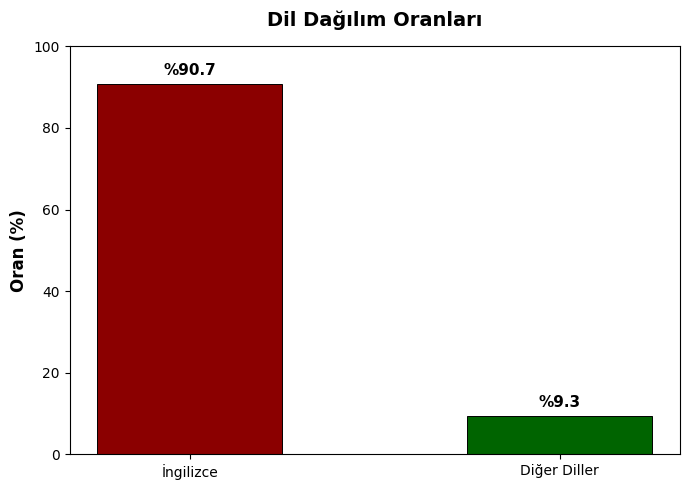

In [3]:
import matplotlib.pyplot as plt

# Veriler
diller = ['İngilizce', 'Diğer Diller']
oranlar = [90.7, 9.3]
renkler = ['#8B0000', '#006400'] # Koyu kırmızı ve koyu yeşil hex kodları

# Grafik boyutu ve tasarımı
plt.figure(figsize=(7, 5))
bars = plt.bar(diller, oranlar, color=renkler, width=0.5, edgecolor='black', linewidth=0.7)

# Değerleri çubukların tam üzerine yazdırma
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'%{yval}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Başlık ve eksen ayarları
plt.title('Dil Dağılım Oranları', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Oran (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 100) # Yüzdelik ekseni daha dengeli göstermek için 100'e sabitledik

# Grafiği net bir şekilde kaydetme ve gösterme
plt.tight_layout()
plt.show()

In [ ]:
df_en = df_temiz[df_temiz["dil"] == "en"].copy()
print(f"İngilizce yorum: {len(df_en)}")
print(f"Çıkarılan: {len(df_temiz) - len(df_en)}")

# Film bazında özet
import numpy as np

df_en["begeni_log"] = np.log1p(df_en["begeni"])
duygu_map = {"positive": 1, "neutral": 0, "negative": -1, "unknown": 0}
df_en["duygu_sayi"] = df_en["duygu"].map(duygu_map)
df_en["agirlikli_skor"] = df_en["duygu_skoru"] * df_en["duygu_sayi"] * df_en["begeni_log"]

film_ozet = df_en.groupby("film_adi").agg(
    toplam_yorum     = ("yorum", "count"),
    pozitif_oran     = ("duygu", lambda x: round((x == "positive").sum() / len(x) * 100, 1)),
    negatif_oran     = ("duygu", lambda x: round((x == "negative").sum() / len(x) * 100, 1)),
    notr_oran        = ("duygu", lambda x: round((x == "neutral").sum() / len(x) * 100, 1)),
    ort_duygu_skoru  = ("duygu_skoru", "mean"),
    agirlikli_duygu  = ("agirlikli_skor", lambda x:
                        round(x.sum() / df_en.loc[x.index, "begeni_log"].sum(), 4)
                        if df_en.loc[x.index, "begeni_log"].sum() > 0 else 0),
    toplam_begeni    = ("begeni", "sum"),
    ort_begeni       = ("begeni", "mean"),
).reset_index()

print(f"\nFilm özeti ({len(film_ozet)} film):")
print(film_ozet.sort_values("agirlikli_duygu", ascending=False).to_string())

# Kaydet
df_en.to_csv("yorumlar_duygu_en.csv", index=False, encoding="utf-8-sig")
film_ozet.to_csv("film_duygu_ozet.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ İki dosya kaydedildi!")

İngilizce yorum: 57036
Çıkarılan: 5815

Film özeti (139 film):
                                        film_adi  toplam_yorum  pozitif_oran  negatif_oran  notr_oran  ort_duygu_skoru  agirlikli_duygu  toplam_begeni   ort_begeni
19                                   Blue Beetle           435          89.4           2.3        8.3         0.916510           0.8935         193326   444.427586
23                                  Bullet Train           477          90.8           3.4        5.9         0.916400           0.8643         104014   218.058700
116                                 The Gray Man           437          89.2           3.9        6.9         0.906627           0.8604          86004   196.805492
36                                  Extraction 2           452          87.4           4.4        8.2         0.895449           0.8515          55854   123.570796
93                             Silent Night 2023           240          88.3           6.7        5.0         0.91857

In [ ]:
import pandas as pd
import numpy as np

# Veriyi yükle
df = pd.read_csv("yorumlar_duygu_en.csv")

# Beğeni log ağırlığı
df["begeni_log"] = np.log1p(df["begeni"])

# Duyguyu sayıya çevir
duygu_map = {"positive": 1, "neutral": 0, "negative": -1, "unknown": 0}
df["duygu_sayi"] = df["duygu"].map(duygu_map)

# Ağırlıklı skor
df["agirlikli_skor"] = df["duygu_skoru"] * df["duygu_sayi"] * df["begeni_log"]

# Film bazında groupby
film_ozet = df.groupby("film_adi").agg(
    toplam_yorum     = ("yorum", "count"),
    pozitif_oran     = ("duygu", lambda x: round((x == "positive").sum() / len(x) * 100, 1)),
    negatif_oran     = ("duygu", lambda x: round((x == "negative").sum() / len(x) * 100, 1)),
    notr_oran        = ("duygu", lambda x: round((x == "neutral").sum() / len(x) * 100, 1)),
    ort_duygu_skoru  = ("duygu_skoru", "mean"),
    agirlikli_duygu  = ("agirlikli_skor", lambda x:
                        round(x.sum() / df.loc[x.index, "begeni_log"].sum(), 4)
                        if df.loc[x.index, "begeni_log"].sum() > 0 else 0),
    toplam_begeni    = ("begeni", "sum"),
    ort_begeni       = ("begeni", "mean"),
).reset_index()

print(f"Toplam film: {len(film_ozet)}")
print(film_ozet.sort_values("agirlikli_duygu", ascending=False).to_string())

# Kaydet
film_ozet.to_csv("film_duygu_ozet.csv", index=False, encoding="utf-8-sig")
film_ozet.to_excel("film_duygu_ozet.xlsx", index=False)
print("✅ Kaydedildi!")

Toplam film: 139
                                        film_adi  toplam_yorum  pozitif_oran  negatif_oran  notr_oran  ort_duygu_skoru  agirlikli_duygu  toplam_begeni   ort_begeni
19                                   Blue Beetle           435          89.4           2.3        8.3         0.916510           0.8935         193326   444.427586
23                                  Bullet Train           477          90.8           3.4        5.9         0.916400           0.8643         104014   218.058700
116                                 The Gray Man           437          89.2           3.9        6.9         0.906627           0.8604          86004   196.805492
36                                  Extraction 2           452          87.4           4.4        8.2         0.895449           0.8515          55854   123.570796
93                             Silent Night 2023           240          88.3           6.7        5.0         0.918571           0.8446          23780    99.083333

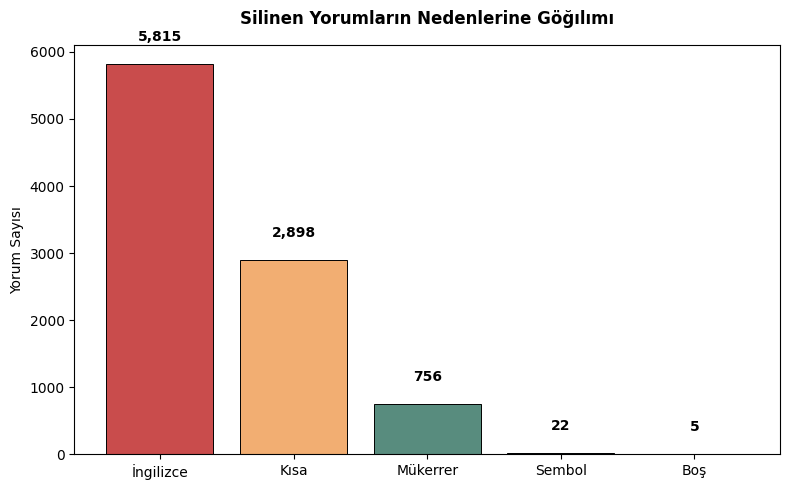

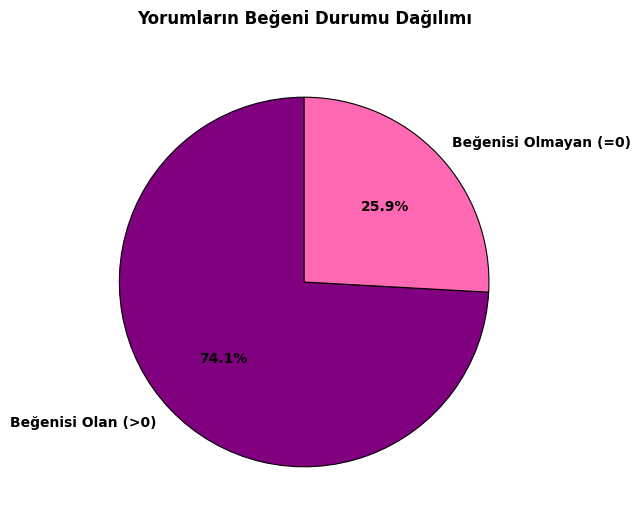

In [3]:
import matplotlib.pyplot as plt

# 1. GRAFİK: Silinme Nedenleri (Sütun Grafiği)
nedenler = ['İngilizce', 'Kısa', 'Mükerrer', 'Sembol', 'Boş']
sayilar = [5815, 2898, 756, 22, 5]
renkler = ['#c94c4c', '#f2ae72', '#588c7e', '#3e4a89', '#96ceb4']

plt.figure(figsize=(8, 5))
bars = plt.bar(nedenler, sayilar, color=renkler, edgecolor='black', linewidth=0.7)

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 300, f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Silinen Yorumların Nedenlerine Göğılımı', fontweight='bold', pad=15)
plt.ylabel('Yorum Sayısı')
plt.tight_layout()
plt.show()

# 2. GRAFİK: Beğeni Durumu (Pasta Grafiği)
plt.figure(figsize=(6, 6))
plt.pie([46587, 16264], labels=['Beğenisi Olan (>0)', 'Beğenisi Olmayan (=0)'],
        colors=['#800080', '#FF69B4'], autopct='%1.1f%%', startangle=90,
        textprops={'fontweight': 'bold'}, wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
plt.title('Yorumların Beğeni Durumu Dağılımı', fontweight='bold', pad=20)
plt.show()